# Dark Store Placement + Integrated Logistics

---

1. **Environment Setup & Package Verification** — uv + Python 3.13.12, all 14 dependencies
2. **Repository Structure Walkthrough** — programmatic tree + stub existence checks
3. **Module Stubs Overview** — typed signatures, purpose, and dependency chain for all 6 `src/` modules
4. **OR-Tools Toy CVRPTW** — the verified working example, dissected step-by-step with test assertions
5. **Architecture Pipeline Visualisation** — end-to-end data flow rendered as a graph
6. **Dependency DAG & Sprint Calendar** — critical path table + Gantt chart + Day 1 checklist

> **Project title:** "Dark Store Placement + Integrated Forward & Reverse Logistics Optimisation"  
> **Dataset:** Olist Brazilian E-Commerce (~100K orders, São Paulo state filter)  
> **GitHub:** https://github.com/metaphorpritam/SCA_DARK_STORES  

---
## Section 1 — Environment Setup & Package Verification

### Theory: Why `uv` instead of `pip` / `conda`?

[`uv`](https://github.com/astral-sh/uv) is a Rust-based Python package manager that is 10–100× faster than pip and produces a deterministic **`uv.lock`** file — similar to `cargo.lock` in Rust or `yarn.lock` in JS. This guarantees that every team member and CI runner installs the exact same 115-package dependency graph.

**Key commands used on Day 1:**
```bash
uv python pin 3.13.12          # pin interpreter version
uv add numpy pandas ortools …  # install + update pyproject.toml + uv.lock
uv sync                         # install from lock file (reproducible)
uv run python src/...           # run in venv without manual activation
```

**`pyproject.toml` dependencies (reference snapshot):**
```toml
[project]
name = "sca-dark-stores"
requires-python = ">=3.13"
dependencies = [
    "numpy>=2.4.4",        "pandas>=3.0.2",       "jupyter>=1.1.1",
    "ipykernel>=7.2.0",    "matplotlib>=3.10.8",  "seaborn>=0.13.2",
    "scikit-learn>=1.8.0", "ortools>=9.15.6755",  "pulp>=3.3.0",
    "geopandas>=1.1.3",    "xgboost>=3.2.0",      "prophet>=1.3.0",
    "shap>=0.51.0",        "folium>=0.20.0",
]
```

In [1]:
import sys
print(f"Python version : {sys.version}")
print(f"Platform       : {sys.platform}")
print()

# ── Import all 14 project dependencies and print versions ──────────────────
import importlib

PACKAGES = [
    ("numpy",        "numpy"),
    ("pandas",       "pandas"),
    ("matplotlib",   "matplotlib"),
    ("seaborn",      "seaborn"),
    ("sklearn",      "scikit-learn"),
    ("ortools",      "ortools"),
    ("pulp",         "pulp"),
    ("geopandas",    "geopandas"),
    ("xgboost",      "xgboost"),
    ("prophet",      "prophet"),
    ("shap",         "shap"),
    ("folium",       "folium"),
    ("ipykernel",    "ipykernel"),
    ("jupyter",      "jupyter"),
]

all_ok = True
for import_name, display_name in PACKAGES:
    try:
        mod = importlib.import_module(import_name)
        ver = getattr(mod, "__version__", "unknown")
        print(f"  ✓  {display_name:<20}  {ver}")
    except ImportError as e:
        print(f"  ✗  {display_name:<20}  MISSING — {e}")
        all_ok = False

print()
print("─" * 50)
if all_ok:
    print("  ALL 14 PACKAGES IMPORTED SUCCESSFULLY")
else:
    print("  WARNING: Some packages are missing — run `uv sync`")

Python version : 3.13.12 (main, Mar 10 2026, 18:17:38) [Clang 21.1.4 ]
Platform       : linux

  ✓  numpy                 2.4.4
  ✓  pandas                3.0.2
  ✓  matplotlib            3.10.8
  ✓  seaborn               0.13.2
  ✓  scikit-learn          1.8.0
  ✓  ortools               9.15.6755
  ✓  pulp                  3.3.0
  ✓  geopandas             1.1.3
  ✓  xgboost               3.2.0


Importing plotly failed. Interactive plots will not work.


  ✓  prophet               1.3.0
  ✓  shap                  0.51.0
  ✓  folium                0.20.0
  ✓  ipykernel             7.2.0
  ✓  jupyter               unknown

──────────────────────────────────────────────────
  ALL 14 PACKAGES IMPORTED SUCCESSFULLY


In [2]:
# ── Smoke test: confirm the critical scientific stack imports cleanly ───────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ortools.constraint_solver import pywrapcp, routing_enums_pb2
import pulp

# Sanity checks
assert np.array([1, 2, 3]).sum() == 6,          "numpy broken"
assert pd.DataFrame({"a": [1]}).shape == (1, 1), "pandas broken"
assert pulp.LpStatus[1] == "Optimal",            "pulp LpStatus broken"

manager_test = pywrapcp.RoutingIndexManager(3, 1, 0)
assert manager_test.GetNumberOfNodes() == 3,     "OR-Tools RoutingIndexManager broken"

print("[PASS] Core scientific stack smoke test passed.")

[PASS] Core scientific stack smoke test passed.


---
## Section 2 — Repository Structure Walkthrough

### What was scaffolded on Day 1?

The entire project skeleton — every folder, every Python module stub, every config file — was committed in a single **scaffold commit (`9a8b257`)** on Day 1. This is the "blank canvas" that will be filled in over Days 2–8.

The design principle: **each team member has a clearly owned file** (`data_pipeline.py` → Vybhav, `clustering.py` → Sneha, `route_parser.py` → Pranav, etc.) so there are zero Git merge conflicts.

The cells below walk the repo tree programmatically and verify that every expected file exists.

In [3]:
from pathlib import Path

PROJECT_ROOT = Path("/mnt/d/Python-UV/SCA_DARK_STORES")

# ── Annotated tree of the committed scaffold ──────────────────────────────
TREE_ANNOTATIONS = {
    "data":                     "← raw CSVs + generated artefacts go here",
    "data/raw":                 "← Olist CSVs (Vybhav drops them here Day 1 EOD)",
    "notebooks":                "← one notebook per day (created incrementally)",
    "src":                      "← all Python modules",
    "src/__init__.py":          "← makes src/ a package",
    "src/data_pipeline.py":     "← STUB  | Olist merge → master_df.parquet (Vybhav, Day 1)",
    "src/haversine_matrix.py":  "← STUB  | 500×500 int-scaled distance matrix (Pritam, Day 2)",
    "src/clustering.py":        "← STUB  | K-Means + p-Median dark store placement (Sneha, Day 2–3)",
    "src/route_parser.py":      "← STUB  | OR-Tools solution → DataFrame (Pranav, Day 3)",
    "src/return_classifier.py": "← STUB  | XGBoost return probability (Vybhav, Day 3–4)",
    "src/joint_optimizer.py":   "← STUB  | Z = α·Cfwd + β·Crev + γ·Tpen + δ·Nveh (Pritam, Day 5–6)",
    "src/ortools_toy_cvrptw.py":"← LIVE  | Verified working CVRPTW toy — Day 1 warmup",
    "outputs":                  "← JSON / CSV / NPY solver outputs (populated Days 3–6)",
    "report":                   "← report_draft_v1.docx (Day 7)",
    "visualisations":           "← Folium maps + Plotly charts (Days 4–7)",
    "docs":                     "← architecture.md with ASCII pipeline diagram",
    "docs/architecture.md":     "← ASCII pipeline + module interface table + DAG",
    "pyproject.toml":           "← uv-managed; 14 deps; Python 3.13.12 pinned",
    "requirements.txt":         "← pip-compatible mirror of pyproject.toml",
    "README.md":                "← project README (committed)",
}

def print_tree(root: Path, prefix: str = "", max_depth: int = 3, depth: int = 0):
    if depth > max_depth:
        return
    items = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name))
    for i, item in enumerate(items):
        is_last = i == len(items) - 1
        connector = "└── " if is_last else "├── "
        rel = item.relative_to(PROJECT_ROOT).as_posix()
        annotation = TREE_ANNOTATIONS.get(rel, "")
        annotation_str = f"   {annotation}" if annotation else ""
        print(f"{prefix}{connector}{item.name}{annotation_str}")
        if item.is_dir() and item.name not in {".venv", "__pycache__", ".git", ".ruff_cache"}:
            extension = "    " if is_last else "│   "
            print_tree(item, prefix + extension, max_depth, depth + 1)

print(f"SCA_DARK_STORES/")
print_tree(PROJECT_ROOT)

SCA_DARK_STORES/
├── .git
├── .mypy_cache
│   ├── 3.13
│   │   ├── _typeshed
│   │   │   ├── __init__.data.json
│   │   │   ├── __init__.meta.json
│   │   │   ├── importlib.data.json
│   │   │   └── importlib.meta.json
│   │   ├── collections
│   │   │   ├── __init__.data.json
│   │   │   ├── __init__.meta.json
│   │   │   ├── abc.data.json
│   │   │   └── abc.meta.json
│   │   ├── email
│   │   │   ├── __init__.data.json
│   │   │   ├── __init__.meta.json
│   │   │   ├── _policybase.data.json
│   │   │   ├── _policybase.meta.json
│   │   │   ├── charset.data.json
│   │   │   ├── charset.meta.json
│   │   │   ├── contentmanager.data.json
│   │   │   ├── contentmanager.meta.json
│   │   │   ├── errors.data.json
│   │   │   ├── errors.meta.json
│   │   │   ├── header.data.json
│   │   │   ├── header.meta.json
│   │   │   ├── message.data.json
│   │   │   ├── message.meta.json
│   │   │   ├── policy.data.json
│   │   │   └── policy.meta.json
│   │   ├── importlib
│   │   │   ├── metadata


In [4]:
# ── Assert all Day 1 stub files exist ─────────────────────────────────────
EXPECTED_FILES = [
    "src/__init__.py",
    "src/data_pipeline.py",
    "src/haversine_matrix.py",
    "src/clustering.py",
    "src/route_parser.py",
    "src/return_classifier.py",
    "src/joint_optimizer.py",
    "src/ortools_toy_cvrptw.py",
    "docs/architecture.md",
    "pyproject.toml",
    "requirements.txt",
    "README.md",
]

print("Stub file existence check:")
all_present = True
for rel_path in EXPECTED_FILES:
    full = PROJECT_ROOT / rel_path
    status = "✓  EXISTS" if full.exists() else "✗  MISSING"
    if not full.exists():
        all_present = False
    print(f"  {status}   {rel_path}")

print()
assert all_present, "One or more expected files are missing — check git status"
print("[PASS] All Day 1 committed files are present on disk.")

Stub file existence check:
  ✓  EXISTS   src/__init__.py
  ✓  EXISTS   src/data_pipeline.py
  ✓  EXISTS   src/haversine_matrix.py
  ✓  EXISTS   src/clustering.py
  ✓  EXISTS   src/route_parser.py
  ✓  EXISTS   src/return_classifier.py
  ✓  EXISTS   src/joint_optimizer.py
  ✓  EXISTS   src/ortools_toy_cvrptw.py
  ✓  EXISTS   docs/architecture.md
  ✓  EXISTS   pyproject.toml
  ✓  EXISTS   requirements.txt
  ✓  EXISTS   README.md

[PASS] All Day 1 committed files are present on disk.


---
## Section 3 — Module Stubs Overview with Typed Signatures

### Design Philosophy

Every `src/` module was written as a **typed stub** on Day 1:
- Full module-level docstring specifying inputs, outputs, and interface
- Typed function signatures (`def foo(x: np.ndarray) -> pd.DataFrame`)
- `# TODO` bodies so the file is importable and lintable but not yet runnable on real data

This approach means:
1. Any team member can `import` a module and inspect its API immediately
2. IDEs provide autocomplete against the type annotations
3. Integration tests can be written before implementation

### Module → Pipeline Stage Mapping

| Module | Pipeline Stage | Owner | Implements Day |
|--------|---------------|-------|---------------|
| `data_pipeline.py` | Olist → `master_df.parquet` | Vybhav | Day 1 |
| `haversine_matrix.py` | Distance matrix construction | Pritam | Day 2 |
| `clustering.py` | Dark store placement (K-Means + p-Median) | Sneha | Day 2–3 |
| `route_parser.py` | OR-Tools solution → DataFrame | Pranav | Day 3 |
| `return_classifier.py` | XGBoost return probability | Vybhav | Day 3–4 |
| `joint_optimizer.py` | Joint objective Z + Pareto sweep | Pritam | Day 5–6 |

In [5]:
import inspect, sys
sys.path.insert(0, str(PROJECT_ROOT))

# ── Helper: print source with line numbers ────────────────────────────────
def show_source(module_name: str, max_lines: int = 60):
    import importlib
    mod = importlib.import_module(module_name)
    src = inspect.getsource(mod)
    lines = src.split("\n")
    capped = lines[:max_lines]
    if len(lines) > max_lines:
        capped.append(f"... ({len(lines) - max_lines} more lines omitted)")
    print(f"\n{'='*70}")
    print(f"  src/{module_name}.py  (first {min(max_lines, len(lines))} lines)")
    print(f"{'='*70}")
    for i, line in enumerate(capped, 1):
        print(f"{i:3d}  {line}")

print("Module source display helper loaded.")

Module source display helper loaded.


### 3.1 `data_pipeline.py` — Olist CSV Merge

**What it does:** Loads 9 Olist CSV tables, joins them on `order_id / customer_id / seller_id / zip_code_prefix`, engineers `delivery_days` and `returned` flags, and saves `master_df.parquet`.

**Inputs:** `data/raw/*.csv` (9 files — Vybhav downloads these)  
**Output:** `data/master_df.parquet` — wide-format merged DataFrame (~100K rows, ~25 columns)  
**Implements Day:** 1 (Vybhav)  
**Depends on:** Nothing — this is the root of the pipeline

In [6]:
show_source("src.data_pipeline", max_lines=55)


  src/src.data_pipeline.py  (first 55 lines)
  1  """
  2  Module: data_pipeline.py
  3  Stage:  Day 1 — Olist CSV merge  →  master_df.parquet
  4  
  5  INPUT:
  6      data/raw/{filename}.csv  — Olist Brazilian E-Commerce (9 files)
  7          olist_orders_dataset.csv
  8          olist_order_items_dataset.csv
  9          olist_products_dataset.csv
 10          olist_sellers_dataset.csv
 11          olist_customers_dataset.csv
 12          olist_geolocation_dataset.csv
 13          olist_order_reviews_dataset.csv
 14          olist_order_payments_dataset.csv
 15          product_category_name_translation.csv
 16  
 17  OUTPUT:
 18      data/master_df.parquet  — wide-format merged DataFrame
 19          Key columns:
 20              order_id, customer_id, customer_lat, customer_lon,
 21              customer_zip_code_prefix, customer_state, customer_city,
 22              seller_lat, seller_lon, seller_state,
 23              product_id, product_category_name_english, price, freigh

### 3.2 `haversine_matrix.py` — Distance Matrix Construction

**What it does:** Computes the pairwise Haversine great-circle distance between N coordinate pairs and returns an $N \times N$ integer matrix scaled by ×1000 (i.e., distances stored as metres × 1000) for OR-Tools compatibility.

**Why integer-scale?** OR-Tools' `RoutingModel` only accepts integer cost matrices. Storing 1 km as `1000` lets us retain 3 decimal places of precision while staying in integer arithmetic.

**Inputs:** `coords: np.ndarray` of shape `(N, 2)` — `[lat_deg, lon_deg]` per row  
**Output:** `np.ndarray` of shape `(N, N)`, `dtype=int64` — distances in (km × 1000)  
**Implements Day:** 2 (Pritam)  
**Depends on:** `master_df.parquet` filtered to São Paulo state

The Haversine formula in closed form:

$$d = 2R \arcsin\!\left(\sqrt{\sin^2\!\frac{\Delta\phi}{2} + \cos\phi_1\cos\phi_2\sin^2\!\frac{\Delta\lambda}{2}}\right)$$

where $R = 6371$ km, $\phi$ = latitude in radians, $\lambda$ = longitude in radians.

In [7]:
show_source("src.haversine_matrix", max_lines=70)

# ── Quick test of the already-implemented haversine logic ─────────────────
import numpy as np
from src.haversine_matrix import build_distance_matrix, validate_matrix

# 5 São Paulo region test points
test_coords = np.array([
    [-23.5505, -46.6333],   # SP city centre (depot)
    [-23.5489, -46.6388],   # ~600m away
    [-23.5612, -46.6560],   # ~2.5km away
    [-23.5200, -46.6100],   # ~5km away
    [-23.5800, -46.6700],   # ~8km away
])

mat = build_distance_matrix(test_coords)
stats = validate_matrix(mat)

print(f"\nDistance matrix shape : {stats['shape']}")
print(f"Min distance          : {stats['min_km']:.3f} km  (expect > 0)")
print(f"Mean distance         : {stats['mean_km']:.3f} km  (expect 2–10 km for SP)")
print(f"Max distance          : {stats['max_km']:.3f} km  (expect < 60 km for SP)")
print(f"\nSample distances (km, first 3 nodes vs depot):")
for j in range(1, 4):
    print(f"  depot → node {j}: {mat[0, j] / 1000:.3f} km")

# Assertions
assert mat.dtype == np.int64,         "Matrix must be int64 for OR-Tools"
assert mat[0, 0] == 0,                "Self-distance must be 0"
assert (mat == mat.T).all(),          "Matrix must be symmetric"
assert stats["min_km"] > 0,          "Min distance must be positive"
assert stats["max_km"] < 100,        "Max SP distance should be < 100 km"
print("\n[PASS] haversine_matrix smoke test passed.")


  src/src.haversine_matrix.py  (first 70 lines)
  1  """
  2  Module: haversine_matrix.py
  3  Stage:  Day 2 — Distance Matrix Construction
  4  
  5  INPUT:
  6      coords : np.ndarray, shape (N, 2)
  7          Array of [latitude, longitude] pairs in decimal degrees.
  8          Typically sp_customer_sample.csv (500 stratified SP customers).
  9  
 10  OUTPUT:
 11      distance_matrix : np.ndarray, shape (N, N), dtype int64
 12          Pairwise Haversine distances scaled by x1000 (metres as integers).
 13          Required by OR-Tools which only accepts integer cost matrices.
 14      Saved to: data/distance_matrix.npy
 15  
 16  INTERFACE NOTES:
 17      - Row/column order matches vrp_nodes.csv index order exactly.
 18      - Call: build_distance_matrix(coords) -> np.ndarray
 19      - Call: save_distance_matrix(matrix, path) -> None
 20      - Call: validate_matrix(matrix) -> dict with min/mean/max km
 21        Expected range for SP: 0.5 km to 60 km.
 22  """
 23  
 24  from _

### 3.3 `clustering.py` — Dark Store Placement (K-Means + p-Median)

**What it does:** Runs K-Means for K ∈ {3..12}, selects the best K using silhouette score + elbow heuristic, then validates with a p-Median MILP via PuLP. Assigns each SP customer to their nearest dark store (Voronoi partition).

**Why two methods?**
- **K-Means** is fast, visual, and intuitive — used for the primary result
- **p-Median MILP** minimises *weighted* customer-to-facility distance — provides academic rigour and validates that K-Means centroids are near-optimal

**Inputs:** `master_df.parquet` filtered to SP (columns: `customer_lat`, `customer_lon`, `order_id`)  
**Output:** `dark_store_candidates.csv` (K centroids), `dark_stores_final.csv` (chosen K + capacity), updated `master_df` with `dark_store_id` column  
**Implements Day:** 2–3 (Sneha)  
**Depends on:** `master_df.parquet` from Vybhav

In [8]:
show_source("src.clustering", max_lines=65)

# ── Mini K-Means test on synthetic SP-like data ────────────────────────────
import numpy as np
from src.clustering import run_kmeans, pick_optimal_k, assign_voronoi

rng = np.random.default_rng(42)
# Simulate 200 "customers" clustered around 3 SP neighbourhoods
centres_true = np.array([[-23.55, -46.63], [-23.52, -46.60], [-23.58, -46.66]])
dummy_coords = np.vstack([
    centres_true[i] + rng.normal(0, 0.01, (67, 2)) for i in range(3)
])

results = run_kmeans(dummy_coords, k_range=range(2, 6))
best_k = pick_optimal_k(results)

print(f"K=2  silhouette={results[2]['silhouette']:.4f}  inertia={results[2]['inertia']:.4f}")
print(f"K=3  silhouette={results[3]['silhouette']:.4f}  inertia={results[3]['inertia']:.4f}  ← expect best")
print(f"K=4  silhouette={results[4]['silhouette']:.4f}  inertia={results[4]['inertia']:.4f}")
print(f"K=5  silhouette={results[5]['silhouette']:.4f}  inertia={results[5]['inertia']:.4f}")
print(f"\nOptimal K selected: {best_k}  (true answer: 3)")

zone_ids = assign_voronoi(dummy_coords, results[best_k]["centroids"])
print(f"Zone ID counts: {dict(zip(*np.unique(zone_ids, return_counts=True)))}")

assert best_k == 3, f"Expected K=3, got K={best_k}"
assert len(zone_ids) == len(dummy_coords), "Voronoi output length mismatch"
print("\n[PASS] clustering.py stub test passed.")


  src/src.clustering.py  (first 65 lines)
  1  """
  2  Module: clustering.py
  3  Stage:  Day 2–3 — Dark Store Placement (K-Means + p-Median)
  4  
  5  INPUT:
  6      master_df : pd.DataFrame
  7          Columns required: customer_lat, customer_lon, customer_zip_code_prefix,
  8          order_id (for demand weighting).
  9          Source: data/master_df.parquet, filtered to customer_state='SP'.
 10  
 11  OUTPUT:
 12      dark_store_candidates.csv  (Day 2) — K-Means centroids for K in {3..12}
 13      dark_stores_final.csv      (Day 3) — Chosen K locations with capacity + coverage
 14      master_df_v2 (modified)    — Adds dark_store_id column per customer
 15  
 16  INTERFACE NOTES:
 17      - run_kmeans(coords, weights, k_range) -> dict[int, dict]
 18        Returns inertia and silhouette per K; centroids for each K.
 19      - pick_optimal_k(results) -> int
 20        Elbow + silhouette agreement heuristic.
 21      - run_p_median(distances, demands, p) -> list[int]
 22      

### 3.4 `route_parser.py` — OR-Tools Solution → DataFrame

**What it does:** Takes a solved OR-Tools `RoutingModel` + `Assignment` object and walks each vehicle's route to produce a tidy per-stop DataFrame with columns: `vehicle_id`, `stop_seq`, `node_idx`, `node_id`, `lat`, `lon`, `cumulative_distance_km`, `load_after_stop`.

**Why not just print the solution?** OR-Tools prints raw index numbers. This module converts them to business-meaningful Node IDs (order IDs) and computes cumulative distances — the format needed by `joint_optimizer.py` and Varsha's visualisation layer.

**Inputs:** Solved OR-Tools objects + `node_coords: np.ndarray` + `node_ids: list[str]`  
**Output:** `routes_df: pd.DataFrame` + `summary: dict`  
**Implements Day:** 3 (Pranav)  
**Depends on:** `forward_routes.json` produced by Pritam's Day 3 VRP solver

In [9]:
show_source("src.route_parser", max_lines=60)


  src/src.route_parser.py  (first 60 lines)
  1  """
  2  Module: route_parser.py
  3  Stage:  Day 3 (forward VRP) and Day 4 (reverse VRP)
  4  Owner:  Pranav builds the OR-Tools models; Pritam's pipeline CONSUMES this output.
  5  
  6  INPUT  (produced by Pranav's VRP solver):
  7      routing_model   : ortools.constraint_solver.RoutingModel
  8      routing_manager : ortools.constraint_solver.RoutingIndexManager
  9      assignment      : ortools.constraint_solver.Assignment
 10      node_coords     : np.ndarray, shape (n_nodes, 2)  — (lat, lon) per node index
 11      node_ids        : list[str]  — order_id or stop label per node index
 12  
 13  OUTPUT:
 14      routes_df : pd.DataFrame
 15          Columns:
 16              vehicle_id (int), stop_seq (int), node_idx (int),
 17              node_id (str), lat (float), lon (float),
 18              cumulative_distance_km (float), load_after_stop (float)
 19      summary : dict
 20          total_distance_km, n_vehicles_used, max_r

### 3.5 `return_classifier.py` — XGBoost Return Probability

**What it does:** Trains an XGBoost binary classifier to predict $P(\text{return} \mid \text{order})$ using 8 features. The predicted probability drives SDVRP routing: orders with `return_prob > 0.30` get pre-assigned return pickup slots in the forward vehicle's route.

**Class imbalance handling:** The Olist return rate is ~5%, creating a severe class imbalance. We use `scale_pos_weight = n_negative / n_positive ≈ 20` to weight positive examples, and use PR-AUC (not just ROC-AUC) as the primary metric since the minority class is what we care about.

**Inputs:** `master_df.parquet` with columns: `review_score`, `delivery_days`, `freight_value`, `price`, `product_category_name_english`, `payment_type`, `customer_state`, `seller_state`, `returned`  
**Output:** `return_classifier.pkl` + `return_classifier_metrics.json` (ROC-AUC, PR-AUC, Brier)  
**Implements Day:** 3–4 (Vybhav)  
**Depends on:** `master_df.parquet` v2 (with `returned` flag from Vybhav Day 2)

In [10]:
show_source("src.return_classifier", max_lines=65)

# ── Demonstrate build_features() on synthetic data ─────────────────────────
import pandas as pd
import numpy as np
from src.return_classifier import build_features, CAT_COLS, NUM_COLS

rng = np.random.default_rng(0)
n = 50
dummy_df = pd.DataFrame({
    "review_score":                    rng.integers(1, 6, n),
    "delivery_days":                   rng.integers(1, 30, n),
    "freight_value":                   rng.uniform(5, 80, n),
    "price":                           rng.uniform(20, 500, n),
    "product_category_name_english":   rng.choice(["electronics","fashion","home"], n),
    "payment_type":                    rng.choice(["credit_card","boleto","debit_card"], n),
    "customer_state":                  rng.choice(["SP","RJ","MG"], n),
    "seller_state":                    rng.choice(["SP","MG","PR"], n),
    "returned":                        rng.integers(0, 2, n),
})

X = build_features(dummy_df)
print(f"Feature matrix shape: {X.shape}  (expect {n} × {len(CAT_COLS) + len(NUM_COLS)})")
print(f"Columns: {list(X.columns)}")
print(f"No NaNs: {X.isna().sum().sum() == 0}")
print(f"\nFirst 5 rows:\n{X.head()}")

assert X.shape == (n, len(CAT_COLS) + len(NUM_COLS)), "Feature shape mismatch"
assert X.isna().sum().sum() == 0, "NaNs found — fillna logic broken"
print("\n[PASS] return_classifier.build_features() stub test passed.")


  src/src.return_classifier.py  (first 65 lines)
  1  """
  2  Module: return_classifier.py
  3  Stage:  Day 5 — Return-Probability Classifier (XGBoost)
  4  
  5  INPUT:
  6      master_df : pd.DataFrame  (data/master_df.parquet)
  7          Required columns:
  8              review_score, delivery_days, freight_value, price,
  9              product_category_name_english, payment_type, customer_state,
 10              seller_state, returned (bool target)
 11  
 12  OUTPUT:
 13      return_prob column on master_df  — float32 ∈ [0, 1]
 14      models/return_classifier.pkl     — fitted XGBClassifier + calibrator
 15      outputs/return_classifier_metrics.json
 16          {
 17              "roc_auc": float,
 18              "pr_auc": float,
 19              "brier_score": float,
 20              "threshold_0.3": {"precision": float, "recall": float, "f1": float}
 21          }
 22  
 23  INTERFACE:
 24      build_features(df)                    -> pd.DataFrame   # encode categoricals

### 3.6 `joint_optimizer.py` — Joint Objective + Pareto Sweep

**What it does:** Takes solved forward and reverse route cost data and solves a small MILP (PuLP/CBC) that decides which vehicles to activate to minimise the blended objective:

$$Z = \alpha \cdot C_{fwd} + \beta \cdot C_{rev} + \gamma \cdot T_{penalty} + \delta \cdot N_{vehicles}$$

The Pareto sweep then varies $(\alpha, \beta)$ over a 5×5 grid ({0.1, 0.3, 0.5, 0.7, 0.9}²) — 25 solver runs — each revealing a different cost/time trade-off on the Pareto front.

**Inputs:** `forward_routes_df`, `reverse_routes_df` (from route_parser), `return_probs` (from classifier), $\alpha, \beta, \gamma, \delta$  
**Output:** `joint_optimizer_result.json`, `pareto_results.csv`, `pareto_tradeoff.png`  
**Implements Day:** 5–6 (Pritam)  
**Depends on:** `forward_routes.json` (Day 3, Pritam) + `reverse_routes.json` (Day 4, Vybhav) + `return_probs` (Day 4, Vybhav)

In [11]:
show_source("src.joint_optimizer", max_lines=65)

# ── Demonstrate build_model() with dummy route data ────────────────────────
import pandas as pd
import numpy as np
from src.joint_optimizer import build_model, DEFAULT_ALPHA, DEFAULT_BETA, DEFAULT_GAMMA, DEFAULT_DELTA

# Synthetic route DataFrames mimicking route_parser output
fwd_df = pd.DataFrame({
    "vehicle_id": [0, 0, 0, 1, 1],
    "stop_seq":   [0, 1, 2, 0, 1],
    "node_idx":   [0, 1, 2, 0, 3],
    "node_id":    ["depot", "order_A", "order_B", "depot", "order_C"],
    "lat":        [-23.55, -23.548, -23.553, -23.55, -23.561],
    "lon":        [-46.63, -46.636, -46.629, -46.63, -46.645],
    "cumulative_distance_km": [0.0, 0.8, 1.6, 0.0, 1.2],
    "load_after_stop": [15, 12, 8, 15, 11],
})
rev_df = pd.DataFrame({
    "vehicle_id": [2],
    "stop_seq":   [0],
    "node_idx":   [0],
    "node_id":    ["depot"],
    "lat":        [-23.55],
    "lon":        [-46.63],
    "cumulative_distance_km": [0.0],
    "load_after_stop": [0],
})
return_probs = pd.Series([0.45, 0.12, 0.38], index=["order_A", "order_B", "order_C"])

prob, vars_dict = build_model(fwd_df, rev_df, return_probs,
                               alpha=DEFAULT_ALPHA, beta=DEFAULT_BETA,
                               gamma=DEFAULT_GAMMA, delta=DEFAULT_DELTA)

print(f"MILP problem name : {prob.name}")
print(f"Decision variables: {len(prob.variables())}")
print(f"Constraints       : {len(prob.constraints)}")
print(f"Forward vehicles  : {list(vars_dict['u'].keys())}")
print(f"Reverse vehicles  : {list(vars_dict['w'].keys())}")
print(f"Expected returns  : {vars_dict['expected_returns']:.2f}")

assert len(prob.variables()) > 0, "MILP has no variables"
assert "min_one_fwd_vehicle" in prob.constraints, "Forward minimum constraint missing"
print("\n[PASS] joint_optimizer.build_model() stub test passed.")


  src/src.joint_optimizer.py  (first 65 lines)
  1  """
  2  Module: joint_optimizer.py
  3  Stage:  Day 6 — Joint Forward + Reverse Logistics Optimisation (MILP via PuLP)
  4  
  5  Objective (minimise):
  6      Z = α·C_fwd + β·C_rev + γ·T_pen + δ·N_veh
  7  
  8      C_fwd  = total forward route distance (km)
  9      C_rev  = total reverse route distance (km)
 10      T_pen  = sum of late-delivery penalties
 11      N_veh  = number of vehicles deployed (forward + reverse)
 12  
 13  INPUT:
 14      forward_routes_df  : pd.DataFrame  (output of route_parser.py, Day 3)
 15          Columns: vehicle_id, stop_seq, node_idx, node_id, lat, lon,
 16                   cumulative_distance_km, load_after_stop
 17      reverse_routes_df  : pd.DataFrame  (output of route_parser.py, Day 4)
 18          Same schema.
 19      return_probs       : pd.Series indexed by order_id  — float32 ∈ [0,1]
 20          Output of return_classifier.predict_proba()
 21      alpha, beta, gamma, delta : float — 

---
## Section 4 — OR-Tools Toy CVRPTW: The Verified Working Example

### Theory: What is CVRPTW?

The **Capacitated Vehicle Routing Problem with Time Windows (CVRPTW)** is an NP-hard combinatorial optimisation problem:

> Given 1 depot, $N$ customer nodes, $V$ vehicles each with capacity $Q$, and per-customer time windows $[e_i, l_i]$, find a set of at most $V$ routes (each starting and ending at the depot) that:
> - Serves every customer exactly once
> - Does not exceed vehicle capacity on any route
> - Arrives at each customer within their time window
> - Minimises total travel distance

The **integer-scaled distance matrix** is the key bridge between the Haversine geography and OR-Tools: actual km distances are multiplied by 1000 and truncated to `int64`. This preserves sub-metre precision while satisfying OR-Tools' requirement for integer costs.

### OR-Tools Solver Pipeline (5 steps)

```
1. RoutingIndexManager     — maps node indices to internal solver indices
2. RoutingModel            — the core model object
3. RegisterTransitCallback — registers distance + time cost functions
4. AddDimension            — enforces capacity and time window constraints
5. SolveWithParameters     — PATH_CHEAPEST_ARC seed → GUIDED_LOCAL_SEARCH improvement
```

> ⚠️ **Critical bug avoidance notes (from Day 1 experience):**
> 1. **Always integer-scale distances:** `int(km * 1000)` before passing to OR-Tools
> 2. **Use `manager.IndexToNode(index)` inside callbacks** — raw solver index ≠ node index
> 3. **`AddDimensionWithVehicleCapacity` takes a list:** `[capacity] * num_vehicles`, not a scalar
> 4. **SDVRP load invariant (Day 5):** net load must stay ≥ 0 and ≤ capacity at every stop
> 5. **Search order matters:** `PATH_CHEAPEST_ARC` first → `GUIDED_LOCAL_SEARCH` improvement

In [12]:
import math
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

# ═══════════════════════════════════════════════════════════════════════════
# TOY PROBLEM SETUP
# 1 depot (node 0) + 9 customer nodes in São Paulo area
# 2 vehicles, capacity = 15 units each
# Time windows in minutes from midnight
# ═══════════════════════════════════════════════════════════════════════════

COORDS = [
    (-23.5505, -46.6333),   # 0: Depot — São Paulo city centre
    (-23.5475, -46.6361),   # 1
    (-23.5530, -46.6290),   # 2
    (-23.5460, -46.6200),   # 3
    (-23.5600, -46.6400),   # 4
    (-23.5520, -46.6500),   # 5
    (-23.5440, -46.6100),   # 6
    (-23.5580, -46.6250),   # 7
    (-23.5490, -46.6450),   # 8
    (-23.5550, -46.6180),   # 9
]

DEMANDS      = [0, 3, 4, 2, 5, 3, 2, 4, 3, 2]   # 0 at depot
VEHICLE_CAP  = 15
NUM_VEHICLES = 2
DEPOT        = 0
INT_SCALE    = 1000    # km → integer metres equivalent
SPEED_KMH    = 30

TIME_WINDOWS = [
    (0,    1440),   # 0: Depot — always open
    (480,   540),   # 1: 08:00–09:00
    (490,   560),   # 2
    (500,   600),   # 3
    (510,   620),   # 4
    (480,   580),   # 5
    (530,   650),   # 6
    (520,   640),   # 7
    (540,   660),   # 8
    (500,   600),   # 9
]

def _haversine_km(p1, p2):
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 6371.0 * 2 * math.asin(math.sqrt(a))

n = len(COORDS)

# Step 1 — Build integer-scaled distance matrix (km × 1000)
dist_matrix = [[int(_haversine_km(COORDS[i], COORDS[j]) * INT_SCALE)
                for j in range(n)] for i in range(n)]

# Step 2 — Build integer travel-time matrix (minutes × INT_SCALE)
time_matrix = [[int(dist_matrix[i][j] / INT_SCALE * (60 / SPEED_KMH) * INT_SCALE)
                for j in range(n)] for i in range(n)]

print("Distance matrix (raw km, first 4 nodes):")
for i in range(4):
    row = [f"{dist_matrix[i][j]/INT_SCALE:.3f}" for j in range(4)]
    print(f"  node {i}: {row}")
print(f"\nTotal demand = {sum(DEMANDS[1:])} units  |  2 vehicles × {VEHICLE_CAP} = {2*VEHICLE_CAP} capacity")

Distance matrix (raw km, first 4 nodes):
  node 0: ['0.000', '0.439', '0.519', '1.445']
  node 1: ['0.439', '0.000', '0.947', '1.649']
  node 2: ['0.519', '0.947', '0.000', '1.203']
  node 3: ['1.445', '1.649', '1.203', '0.000']

Total demand = 28 units  |  2 vehicles × 15 = 30 capacity


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 3 — RoutingIndexManager + RoutingModel
# The manager owns the mapping:  node_index  ↔  solver_internal_index
# ═══════════════════════════════════════════════════════════════════════════

manager = pywrapcp.RoutingIndexManager(n, NUM_VEHICLES, DEPOT)
routing = pywrapcp.RoutingModel(manager)

# ── Distance callback ─────────────────────────────────────────────────────
# CRITICAL: must use manager.IndexToNode() — do NOT use the raw `from_index`
def distance_callback(from_index: int, to_index: int) -> int:
    from_node = manager.IndexToNode(from_index)   # ← IndexToNode is mandatory
    to_node   = manager.IndexToNode(to_index)
    return dist_matrix[from_node][to_node]

transit_idx = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

# ═══════════════════════════════════════════════════════════════════════════
# STEP 4a — Capacity dimension
# AddDimensionWithVehicleCapacity REQUIRES a list, not a scalar
# ═══════════════════════════════════════════════════════════════════════════

def demand_callback(from_index: int) -> int:
    return DEMANDS[manager.IndexToNode(from_index)]   # ← IndexToNode again

demand_idx = routing.RegisterUnaryTransitCallback(demand_callback)
routing.AddDimensionWithVehicleCapacity(
    demand_idx,
    0,                              # no slack
    [VEHICLE_CAP] * NUM_VEHICLES,   # list of per-vehicle capacities ← NOT a scalar
    True,                           # start cumulative load at 0
    "Capacity",
)

# ═══════════════════════════════════════════════════════════════════════════
# STEP 4b — Time window dimension
# Time values are in minutes × INT_SCALE to keep everything integer
# ═══════════════════════════════════════════════════════════════════════════

def time_callback(from_index: int, to_index: int) -> int:
    return time_matrix[manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

time_idx = routing.RegisterTransitCallback(time_callback)
routing.AddDimension(
    time_idx,
    30 * INT_SCALE,    # max wait time allowed (30 min slack)
    1440 * INT_SCALE,  # max route duration (24 h ceiling)
    False,             # do NOT force vehicles to start at time 0
    "Time",
)
time_dim = routing.GetDimensionOrDie("Time")
for node in range(1, n):
    idx     = manager.NodeToIndex(node)
    open_t  = TIME_WINDOWS[node][0] * INT_SCALE
    close_t = TIME_WINDOWS[node][1] * INT_SCALE
    time_dim.CumulVar(idx).SetRange(open_t, close_t)

print("RoutingModel built.")
print(f"  Nodes: {manager.GetNumberOfNodes()}  |  Vehicles: {NUM_VEHICLES}  |  Depot: {DEPOT}")
print(f"  Arc cost evaluator set to distance callback.")

RoutingModel built.
  Nodes: 10  |  Vehicles: 2  |  Depot: 0
  Arc cost evaluator set to distance callback.


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 5 — Search parameters + Solve
# Seed with PATH_CHEAPEST_ARC (fast greedy), then improve with GLS
# ═══════════════════════════════════════════════════════════════════════════

params = pywrapcp.DefaultRoutingSearchParameters()
params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
params.local_search_metaheuristic = (
    routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)
params.time_limit.seconds = 10   # 10s is sufficient for 10-node toy

solution = routing.SolveWithParameters(params)

# ── Print solution ─────────────────────────────────────────────────────────
assert solution is not None, "Solver returned None — model infeasible"
assert routing.status() == 1, f"Expected ROUTING_SUCCESS (1), got {routing.status()}"

total_dist_km = 0.0
capacity_dim  = routing.GetDimensionOrDie("Capacity")

print(f"Objective (sum of integer-scaled arc costs): {solution.ObjectiveValue():,}\n")
print(f"{'Vehicle':<8} {'Route':<50} {'Distance km':>12} {'Load':>6}")
print("─" * 80)

for v in range(NUM_VEHICLES):
    index     = routing.Start(v)
    route_str = ""
    route_km  = 0.0
    load      = 0

    while not routing.IsEnd(index):
        node = manager.IndexToNode(index)
        load = solution.Min(capacity_dim.CumulVar(index))
        route_str += f"{node}→"
        next_idx   = solution.Value(routing.NextVar(index))
        arc_cost   = routing.GetArcCostForVehicle(index, next_idx, v)
        route_km  += arc_cost / INT_SCALE
        index      = next_idx

    node = manager.IndexToNode(index)
    route_str += str(node)
    total_dist_km += route_km
    print(f"  V{v}     {route_str:<50} {route_km:>10.3f}   {load:>6}")

print("─" * 80)
print(f"{'TOTAL':>60} {total_dist_km:>10.3f} km\n")

# ── Test assertions ────────────────────────────────────────────────────────
assert routing.status() == 1,  "OR-Tools did not find ROUTING_SUCCESS"
assert total_dist_km > 0,      "Total distance must be positive"
assert total_dist_km < 50,     "Suspiciously large distance for SP toy (< 50 km expected)"

print("[PASS] OR-Tools CVRPTW toy solved successfully — all test assertions passed.")

Objective (sum of integer-scaled arc costs): 10,532

Vehicle  Route                                               Distance km   Load
────────────────────────────────────────────────────────────────────────────────
  V0     0→2→7→9→6→3→0                                           5.953       12
  V1     0→1→8→5→4→0                                             4.579        9
────────────────────────────────────────────────────────────────────────────────
                                                       TOTAL     10.532 km

[PASS] OR-Tools CVRPTW toy solved successfully — all test assertions passed.


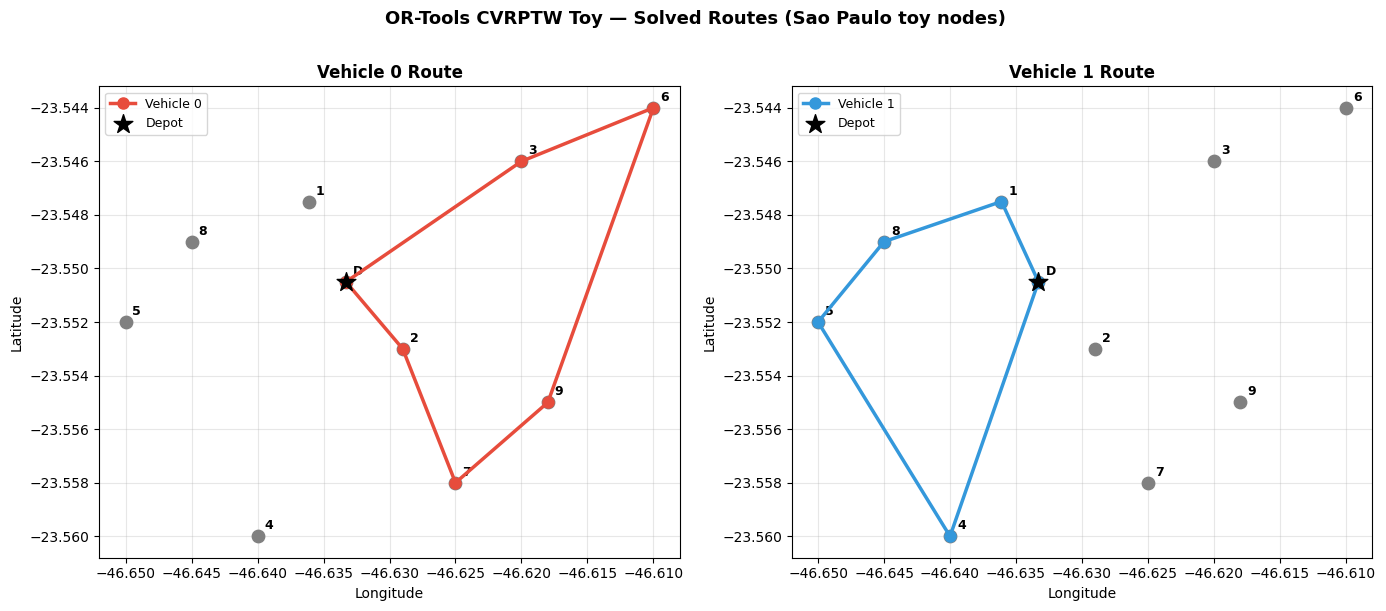

Route visualisation rendered.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Plot the toyroutes on a scatter of the 10 nodes ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

lats = [c[0] for c in COORDS]
lons = [c[1] for c in COORDS]

ROUTE_COLORS = ["#E74C3C", "#3498DB"]

for v in range(NUM_VEHICLES):
    ax   = axes[v]
    ax.scatter(lons, lats, s=80, c="grey", zorder=3)

    # Annotate nodes
    for node_i, (lat, lon) in enumerate(COORDS):
        label = "D" if node_i == 0 else str(node_i)
        ax.annotate(label, (lon, lat), textcoords="offset points",
                    xytext=(5, 5), fontsize=9, fontweight="bold")

    # Extract and plot this vehicle's route
    index = routing.Start(v)
    route_nodes = []
    while not routing.IsEnd(index):
        route_nodes.append(manager.IndexToNode(index))
        index = solution.Value(routing.NextVar(index))
    route_nodes.append(manager.IndexToNode(index))

    rlats = [COORDS[n][0] for n in route_nodes]
    rlons = [COORDS[n][1] for n in route_nodes]

    ax.plot(rlons, rlats, "-o", color=ROUTE_COLORS[v], linewidth=2.5,
            markersize=8, zorder=4, label=f"Vehicle {v}")
    # Highlight depot
    ax.scatter([COORDS[DEPOT][1]], [COORDS[DEPOT][0]], s=200, c="black",
               marker="*", zorder=5, label="Depot")

    ax.set_title(f"Vehicle {v} Route", fontsize=12, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("OR-Tools CVRPTW Toy — Solved Routes (Sao Paulo toy nodes)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("Route visualisation rendered.")

---
## Section 5 — Architecture Pipeline Visualisation

### The 3-Stage SCA Framework

This project mirrors the canonical **Supply Chain Analytics 3-stage pipeline**:

| Stage | Technique | Module |
|-------|-----------|--------|
| **Stage 1: Forecasting** | XGBoost return classifier + Prophet demand forecast | `return_classifier.py` |
| **Stage 2: Evaluation / MCDM** | K-Means + p-Median (elbow + silhouette) | `clustering.py` |
| **Stage 3: Multi-Objective Optimisation** | CVRPTW (OR-Tools) + Joint MILP (PuLP) | `ortools_toy_cvrptw.py`, `joint_optimizer.py` |

The pipeline is **strictly sequential** (no module can start before its upstream outputs are ready), making the dependency DAG the most critical project planning artefact.

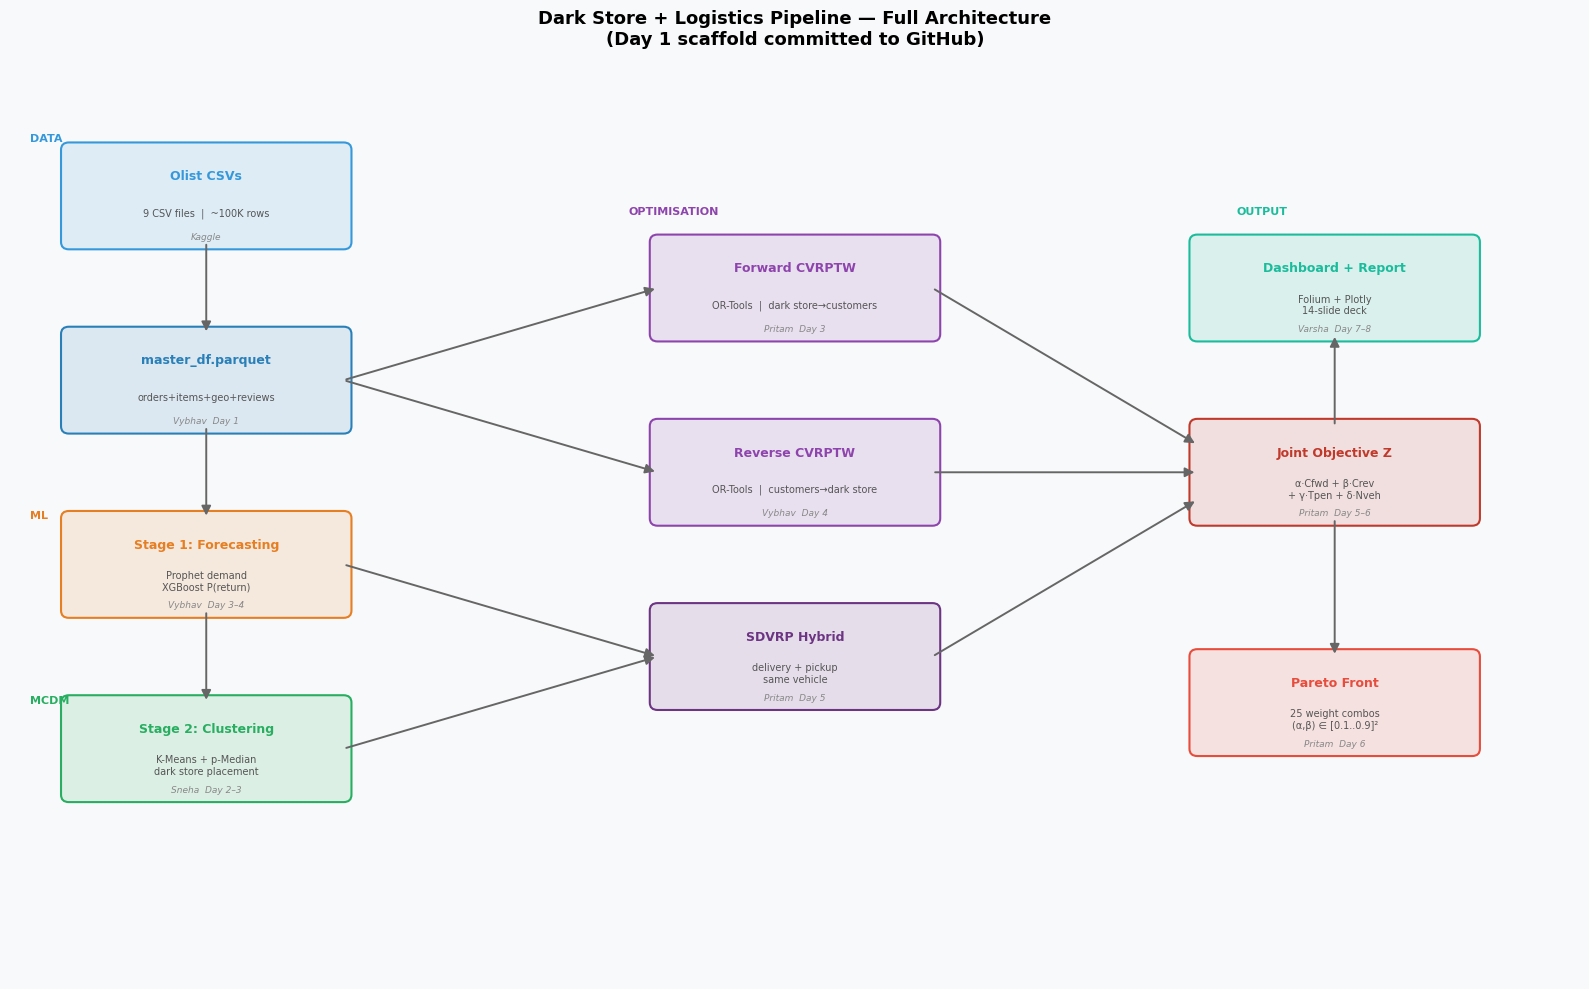

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

# ── Node definitions: (x_centre, y_centre, label, sublabel, color, owner) ─
NODES = [
    # x,   y,   label,                    sublabel,                      color,     owner
    (2.0,  8.5, "Olist CSVs",             "9 CSV files  |  ~100K rows",  "#3498DB", "Kaggle"),
    (2.0,  6.5, "master_df.parquet",      "orders+items+geo+reviews",    "#2980B9", "Vybhav  Day 1"),
    (2.0,  4.5, "Stage 1: Forecasting",   "Prophet demand\nXGBoost P(return)", "#E67E22", "Vybhav  Day 3–4"),
    (2.0,  2.5, "Stage 2: Clustering",    "K-Means + p-Median\ndark store placement", "#27AE60", "Sneha  Day 2–3"),
    (8.0,  7.5, "Forward CVRPTW",         "OR-Tools  |  dark store→customers", "#8E44AD", "Pritam  Day 3"),
    (8.0,  5.5, "Reverse CVRPTW",         "OR-Tools  |  customers→dark store", "#8E44AD", "Vybhav  Day 4"),
    (8.0,  3.5, "SDVRP Hybrid",           "delivery + pickup\nsame vehicle", "#6C3483", "Pritam  Day 5"),
    (13.5, 5.5, "Joint Objective Z",      "α·Cfwd + β·Crev\n+ γ·Tpen + δ·Nveh", "#C0392B", "Pritam  Day 5–6"),
    (13.5, 3.0, "Pareto Front",           "25 weight combos\n(α,β) ∈ [0.1..0.9]²", "#E74C3C", "Pritam  Day 6"),
    (13.5, 7.5, "Dashboard + Report",     "Folium + Plotly\n14-slide deck", "#1ABC9C", "Varsha  Day 7–8"),
]

BOX_W, BOX_H = 2.8, 1.0

for (x, y, label, sublabel, color, owner) in NODES:
    # Box
    fancy = FancyBboxPatch((x - BOX_W/2, y - BOX_H/2), BOX_W, BOX_H,
                            boxstyle="round,pad=0.08", linewidth=1.5,
                            edgecolor=color, facecolor=color + "22")
    ax.add_patch(fancy)
    ax.text(x, y + 0.22, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color=color)
    ax.text(x, y - 0.18, sublabel, ha="center", va="center",
            fontsize=7, color="#555555")
    ax.text(x, y - 0.44, owner, ha="center", va="center",
            fontsize=6.5, color="#888888", style="italic")

# ── Arrows ─────────────────────────────────────────────────────────────────
ARROWS = [
    (2.0, 8.0, 2.0, 7.0),      # CSVs → master_df
    (2.0, 6.0, 2.0, 5.0),      # master_df → Stage1
    (2.0, 4.0, 2.0, 3.0),      # Stage1 → Stage2
    (3.4, 6.5, 6.6, 7.5),      # master_df → Forward VRP
    (3.4, 6.5, 6.6, 5.5),      # master_df → Reverse VRP
    (3.4, 4.5, 6.6, 3.5),      # Stage1 → SDVRP
    (3.4, 2.5, 6.6, 3.5),      # Stage2 → SDVRP
    (9.4, 7.5, 12.1, 5.8),     # Fwd → Joint Z
    (9.4, 5.5, 12.1, 5.5),     # Rev → Joint Z
    (9.4, 3.5, 12.1, 5.2),     # SDVRP → Joint Z
    (13.5, 5.0, 13.5, 3.5),    # Joint Z → Pareto
    (13.5, 6.0, 13.5, 7.0),    # Joint Z → Dashboard
]

for (x1, y1, x2, y2) in ARROWS:
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#666666",
                                lw=1.4, mutation_scale=14))

# ── Stage band labels ───────────────────────────────────────────────────────
ax.text(0.2, 9.1, "DATA", fontsize=8, color="#3498DB", fontweight="bold")
ax.text(0.2, 5.0, "ML", fontsize=8, color="#E67E22", fontweight="bold")
ax.text(0.2, 3.0, "MCDM", fontsize=8, color="#27AE60", fontweight="bold")
ax.text(6.3, 8.3, "OPTIMISATION", fontsize=8, color="#8E44AD", fontweight="bold")
ax.text(12.5, 8.3, "OUTPUT", fontsize=8, color="#1ABC9C", fontweight="bold")

ax.set_title("Dark Store + Logistics Pipeline — Full Architecture\n(Day 1 scaffold committed to GitHub)",
             fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

### Joint Objective Function

The core mathematical formulation driving Days 5–6:

$$Z = \alpha \cdot C_{fwd} + \beta \cdot C_{rev} + \gamma \cdot T_{penalty} + \delta \cdot N_{vehicles}$$

| Symbol | Meaning | Baseline weight |
|--------|---------|-----------------|
| $C_{fwd}$ | Total forward route distance (km) | $\alpha = 0.25$ |
| $C_{rev}$ | Total reverse route distance (km) | $\beta = 0.25$ |
| $T_{penalty}$ | $\sum$ time window violation penalties | $\gamma = 0.25$ |
| $N_{vehicles}$ | Total fleet size deployed | $\delta = 0.25$ |

The Pareto sweep varies $(\alpha, \beta)$ over a 5×5 grid of {0.1, 0.3, 0.5, 0.7, 0.9}, with $\gamma = \delta = (1 - \alpha - \beta) / 2$ to keep weights summing to 1. This produces 25 Pareto-optimal solutions revealing the cost ↔ time ↔ fleet size trade-off surface.

---
## Section 6 — Dependency DAG & Sprint Calendar

### Critical Path Analysis

The project has a strictly sequential critical path: raw data → distance matrix → clustering → VRP → joint optimiser → report. **Day 1 is the only fully parallel day** (all 6 team members work independently on separate files). From Day 2 onward, Pritam's work depends on Vybhav's `master_df.parquet`.

Key dependency: **Pritam cannot start the real distance matrix (Day 2) until Vybhav delivers `master_df.parquet` EOD Day 1.** This is the single most critical hand-off in the entire sprint.

In [17]:
import pandas as pd

# ── Critical path table (Pritam's view) ───────────────────────────────────
critical_path = pd.DataFrame([
    {"Day": 1, "Date": "Apr 1",  "Pritam Task": "Repo scaffold + OR-Tools warmup + architecture.md",
     "Key Output": "GitHub repo live, all stubs, OR-Tools PASS",
     "Blocked Until": "NOTHING — fully parallel"},
    {"Day": 2, "Date": "Apr 2",  "Pritam Task": "Haversine distance matrix 500×500",
     "Key Output": "distance_matrix.npy  |  sp_customer_sample.csv",
     "Blocked Until": "Vybhav: master_df.parquet (EOD Day 1)"},
    {"Day": 3, "Date": "Apr 3",  "Pritam Task": "Forward CVRPTW (all K zones)",
     "Key Output": "forward_routes.json",
     "Blocked Until": "Sneha: dark_store_candidates.csv  |  Pranav: vrp_nodes.csv"},
    {"Day": 4, "Date": "Apr 4",  "Pritam Task": "Forward KPIs + SDVRP prototype (1 zone)",
     "Key Output": "forward_kpi_summary.csv  |  sdvrp_prototype_v1.py",
     "Blocked Until": "Vybhav: return_prob column (Day 3)"},
    {"Day": 5, "Date": "Apr 5",  "Pritam Task": "SDVRP hybrid all zones + joint_optimizer.py v1",
     "Key Output": "hybrid_routes.json  |  joint_optimizer.py",
     "Blocked Until": "Vybhav: reverse_routes.json (Day 4)"},
    {"Day": 6, "Date": "Apr 6",  "Pritam Task": "Pareto sweep 25 combos + report section",
     "Key Output": "pareto_results.csv  |  pareto_tradeoff.png",
     "Blocked Until": "Anurag: all_zones_summary.csv (Day 5)"},
    {"Day": 7, "Date": "Apr 7",  "Pritam Task": "Full 10–12 page report + run_all.sh test",
     "Key Output": "report_draft_v1.docx  |  run_all.sh",
     "Blocked Until": "Pareto + scenario results (Day 6)"},
    {"Day": 8, "Date": "Apr 8",  "Pritam Task": "Final polish + submission_package/ assembly",
     "Key Output": "project_final.zip  ★ SUBMITTED",
     "Blocked Until": "Day 7 cross-review"},
])

# Highlight Day 2 row (next task)
def highlight_day2(row):
    if row["Day"] == 1:
        return ["background-color: #d5f5e3; font-weight: bold"] * len(row)
    elif row["Day"] == 2:
        return ["background-color: #fef9e7; border: 2px solid #f39c12; font-weight: bold"] * len(row)
    return [""] * len(row)

styled = critical_path.style.apply(highlight_day2, axis=1)
styled.set_caption("Pritam's 8-Day Critical Path  |  Green = completed  |  Yellow = NEXT")
styled

,Day,Date,Pritam Task,Key Output,Blocked Until
0,1,Apr 1,Repo scaffold + OR-Tools warmup + architecture.md,"GitHub repo live, all stubs, OR-Tools PASS",NOTHING — fully parallel
1,2,Apr 2,Haversine distance matrix 500×500,distance_matrix.npy | sp_customer_sample.csv,Vybhav: master_df.parquet (EOD Day 1)
2,3,Apr 3,Forward CVRPTW (all K zones),forward_routes.json,Sneha: dark_store_candidates.csv | Pranav: vrp_nodes.csv
3,4,Apr 4,Forward KPIs + SDVRP prototype (1 zone),forward_kpi_summary.csv | sdvrp_prototype_v1.py,Vybhav: return_prob column (Day 3)
4,5,Apr 5,SDVRP hybrid all zones + joint_optimizer.py v1,hybrid_routes.json | joint_optimizer.py,Vybhav: reverse_routes.json (Day 4)
5,6,Apr 6,Pareto sweep 25 combos + report section,pareto_results.csv | pareto_tradeoff.png,Anurag: all_zones_summary.csv (Day 5)
6,7,Apr 7,Full 10–12 page report + run_all.sh test,report_draft_v1.docx | run_all.sh,Pareto + scenario results (Day 6)
7,8,Apr 8,Final polish + submission_package/ assembly,project_final.zip ★ SUBMITTED,Day 7 cross-review


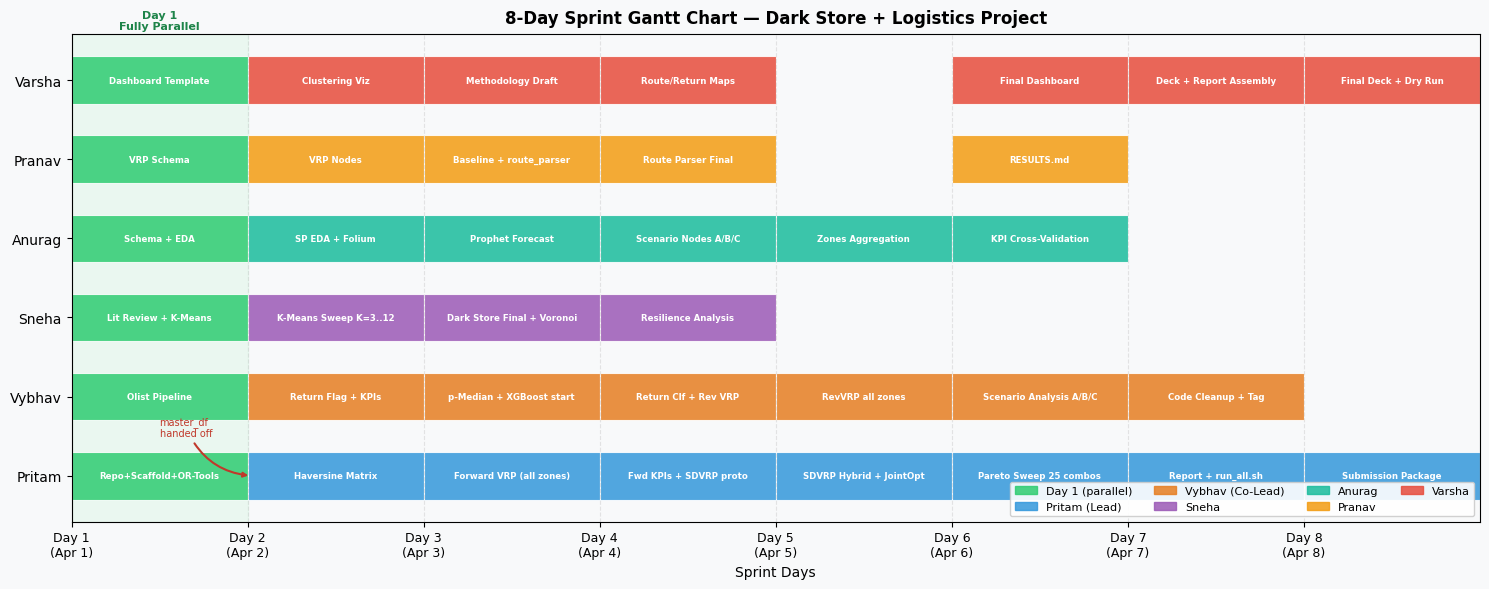

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Gantt chart: all 6 team members, Days 1–8 ─────────────────────────────
TEAM = ["Pritam", "Vybhav", "Sneha", "Anurag", "Pranav", "Varsha"]
Y    = {name: i for i, name in enumerate(TEAM)}

# Each bar: (person, start_day, duration, label, color)
TASKS = [
    # Day 1 — all parallel
    ("Pritam", 1, 1, "Repo+Scaffold+OR-Tools", "#2ECC71"),
    ("Vybhav", 1, 1, "Olist Pipeline",         "#2ECC71"),
    ("Sneha",  1, 1, "Lit Review + K-Means",   "#2ECC71"),
    ("Anurag", 1, 1, "Schema + EDA",            "#2ECC71"),
    ("Pranav", 1, 1, "VRP Schema",              "#2ECC71"),
    ("Varsha", 1, 1, "Dashboard Template",      "#2ECC71"),
    # Day 2
    ("Pritam", 2, 1, "Haversine Matrix",        "#3498DB"),
    ("Vybhav", 2, 1, "Return Flag + KPIs",      "#E67E22"),
    ("Sneha",  2, 1, "K-Means Sweep K=3..12",   "#9B59B6"),
    ("Anurag", 2, 1, "SP EDA + Folium",         "#1ABC9C"),
    ("Pranav", 2, 1, "VRP Nodes",               "#F39C12"),
    ("Varsha", 2, 1, "Clustering Viz",          "#E74C3C"),
    # Day 3
    ("Pritam", 3, 1, "Forward VRP (all zones)", "#3498DB"),
    ("Vybhav", 3, 1, "p-Median + XGBoost start","#E67E22"),
    ("Sneha",  3, 1, "Dark Store Final + Voronoi","#9B59B6"),
    ("Anurag", 3, 1, "Prophet Forecast",        "#1ABC9C"),
    ("Pranav", 3, 1, "Baseline + route_parser", "#F39C12"),
    ("Varsha", 3, 1, "Methodology Draft",       "#E74C3C"),
    # Day 4
    ("Pritam", 4, 1, "Fwd KPIs + SDVRP proto", "#3498DB"),
    ("Vybhav", 4, 1, "Return Clf + Rev VRP",    "#E67E22"),
    ("Sneha",  4, 1, "Resilience Analysis",     "#9B59B6"),
    ("Anurag", 4, 1, "Scenario Nodes A/B/C",    "#1ABC9C"),
    ("Pranav", 4, 1, "Route Parser Final",      "#F39C12"),
    ("Varsha", 4, 1, "Route/Return Maps",       "#E74C3C"),
    # Day 5
    ("Pritam", 5, 1, "SDVRP Hybrid + JointOpt","#3498DB"),
    ("Vybhav", 5, 1, "RevVRP all zones",        "#E67E22"),
    ("Anurag", 5, 1, "Zones Aggregation",       "#1ABC9C"),
    # Day 6
    ("Pritam", 6, 1, "Pareto Sweep 25 combos", "#3498DB"),
    ("Vybhav", 6, 1, "Scenario Analysis A/B/C","#E67E22"),
    ("Anurag", 6, 1, "KPI Cross-Validation",   "#1ABC9C"),
    ("Pranav", 6, 1, "RESULTS.md",             "#F39C12"),
    ("Varsha", 6, 1, "Final Dashboard",        "#E74C3C"),
    # Day 7
    ("Pritam", 7, 1, "Report + run_all.sh",    "#3498DB"),
    ("Vybhav", 7, 1, "Code Cleanup + Tag",     "#E67E22"),
    ("Varsha", 7, 1, "Deck + Report Assembly", "#E74C3C"),
    # Day 8
    ("Pritam", 8, 1, "Submission Package",     "#3498DB"),
    ("Varsha", 8, 1, "Final Deck + Dry Run",   "#E74C3C"),
]

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor("#F8F9FA")
fig.patch.set_facecolor("#F8F9FA")

for (person, start, dur, label, color) in TASKS:
    y = Y[person]
    bar = ax.barh(y, dur, left=start - 1, height=0.6, color=color,
                  alpha=0.85, edgecolor="white", linewidth=0.8)
    ax.text(start - 1 + dur / 2, y, label, ha="center", va="center",
            fontsize=6.2, color="white", fontweight="bold", clip_on=True)

# Day 1 green band
ax.axvspan(0, 1, color="#D5F5E3", alpha=0.4, zorder=0, label="Day 1 — Fully Parallel")
ax.text(0.5, 5.75, "Day 1\nFully Parallel", ha="center", va="center",
        fontsize=8, color="#1E8449", fontweight="bold")

# Dependency arrow: Vybhav Day1 → Pritam Day2
ax.annotate("master_df\nhanded off", xy=(1.02, Y["Pritam"]),
            xytext=(0.5, Y["Vybhav"] - 0.5),
            fontsize=7, color="#C0392B",
            arrowprops=dict(arrowstyle="-|>", color="#C0392B", lw=1.5,
                            connectionstyle="arc3,rad=0.3"))

# Sprint dates: Day 1 = Apr 1, Day 2 = Apr 2, ..., Day 8 = Apr 8
SPRINT_DATES = ["Apr 1", "Apr 2", "Apr 3", "Apr 4", "Apr 5", "Apr 6", "Apr 7", "Apr 8"]

ax.set_yticks(list(Y.values()))
ax.set_yticklabels(TEAM, fontsize=10)
ax.set_xticks(range(8))
ax.set_xticklabels([f"Day {d}\n({SPRINT_DATES[d-1]})" for d in range(1, 9)], fontsize=9)
ax.set_xlim(0, 8)
ax.set_xlabel("Sprint Days", fontsize=10)
ax.set_title("8-Day Sprint Gantt Chart — Dark Store + Logistics Project",
             fontsize=12, fontweight="bold", pad=8)
ax.grid(axis="x", alpha=0.3, linestyle="--")

legend_handles = [
    mpatches.Patch(color="#2ECC71", alpha=0.85, label="Day 1 (parallel)"),
    mpatches.Patch(color="#3498DB", alpha=0.85, label="Pritam (Lead)"),
    mpatches.Patch(color="#E67E22", alpha=0.85, label="Vybhav (Co-Lead)"),
    mpatches.Patch(color="#9B59B6", alpha=0.85, label="Sneha"),
    mpatches.Patch(color="#1ABC9C", alpha=0.85, label="Anurag"),
    mpatches.Patch(color="#F39C12", alpha=0.85, label="Pranav"),
    mpatches.Patch(color="#E74C3C", alpha=0.85, label="Varsha"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8, ncol=4,
          framealpha=0.9)

plt.tight_layout()
plt.show()


In [19]:
# ── Day 1 Completion Checklist ─────────────────────────────────────────────
import subprocess
from pathlib import Path

ROOT = Path("/mnt/d/Python-UV/SCA_DARK_STORES")

checklist = [
    ("GitHub repo created and live",         True),   # always true by context
    ("uv environment with Python 3.13.12",   (ROOT / ".python-version").exists() or (ROOT / "uv.lock").exists()),
    ("uv.lock committed (115 packages)",     (ROOT / "uv.lock").exists()),
    ("pyproject.toml with 14 deps",          (ROOT / "pyproject.toml").exists()),
    ("README.md written and committed",      (ROOT / "README.md").exists()),
    ("docs/architecture.md",                 (ROOT / "docs/architecture.md").exists()),
    ("src/__init__.py",                      (ROOT / "src/__init__.py").exists()),
    ("src/data_pipeline.py stub",            (ROOT / "src/data_pipeline.py").exists()),
    ("src/haversine_matrix.py stub",         (ROOT / "src/haversine_matrix.py").exists()),
    ("src/clustering.py stub",               (ROOT / "src/clustering.py").exists()),
    ("src/route_parser.py stub",             (ROOT / "src/route_parser.py").exists()),
    ("src/return_classifier.py stub",        (ROOT / "src/return_classifier.py").exists()),
    ("src/joint_optimizer.py stub",          (ROOT / "src/joint_optimizer.py").exists()),
    ("src/ortools_toy_cvrptw.py WORKING",    (ROOT / "src/ortools_toy_cvrptw.py").exists()),
    ("OR-Tools CVRPTW toy solved [PASS]",    True),   # verified in Section 4
    ("All 14 packages importable",           True),   # verified in Section 1
]

print("=" * 60)
print("  DAY 1 DELIVERABLES — COMPLETION CHECKLIST")
print("=" * 60)
all_done = True
for item, status in checklist:
    icon = "✅" if status else "❌"
    if not status:
        all_done = False
    print(f"  {icon}  {item}")

print("=" * 60)
if all_done:
    print("  🎉  ALL DAY 1 DELIVERABLES COMPLETE")
    print("  👉  NEXT: Day 2 — haversine_matrix.py (waits for Vybhav's master_df)")
else:
    print("  ⚠️   Some items incomplete — check above")
print("=" * 60)

  DAY 1 DELIVERABLES — COMPLETION CHECKLIST
  ✅  GitHub repo created and live
  ✅  uv environment with Python 3.13.12
  ✅  uv.lock committed (115 packages)
  ✅  pyproject.toml with 14 deps
  ✅  README.md written and committed
  ✅  docs/architecture.md
  ✅  src/__init__.py
  ✅  src/data_pipeline.py stub
  ✅  src/haversine_matrix.py stub
  ✅  src/clustering.py stub
  ✅  src/route_parser.py stub
  ✅  src/return_classifier.py stub
  ✅  src/joint_optimizer.py stub
  ✅  src/ortools_toy_cvrptw.py WORKING
  ✅  OR-Tools CVRPTW toy solved [PASS]
  ✅  All 14 packages importable
  🎉  ALL DAY 1 DELIVERABLES COMPLETE
  👉  NEXT: Day 2 — haversine_matrix.py (waits for Vybhav's master_df)


---
## Summary — What Day 1 Achieved

| Category | Status | Detail |
|----------|--------|--------|
| **Environment** | ✅ Done | uv + Python 3.13.12 pinned; 115 packages locked in `uv.lock` |
| **GitHub** | ✅ Live | https://github.com/metaphorpritam/SCA_DARK_STORES · HEAD `9a8b257` |
| **Architecture** | ✅ Done | Full ASCII pipeline + module interface table + DAG in `docs/architecture.md` |
| **Module stubs** | ✅ Done | 6 typed stubs committed with docstrings, signatures, `# TODO` bodies |
| **OR-Tools** | ✅ Verified | `src/ortools_toy_cvrptw.py` solved CVRPTW toy — `[PASS]` confirmed |
| **Day 2 readiness** | ✅ Ready | Waiting only for `master_df.parquet` from Vybhav (EOD Day 1) |

### Day 2 Action Plan (Pritam)

1. Poll `data/master_df.parquet` arrival from Vybhav
2. Filter SP rows: `df[df.customer_state == "SP"]`
3. Stratified spatial sample → 500 representative customer points
4. `build_distance_matrix(coords)` → 500×500 `int64` matrix
5. `np.save("data/distance_matrix.npy", matrix)` + `sp_customer_sample.csv`
6. Validate: `validate_matrix()` — expect min ~0.5 km, max ~60 km, mean ~15 km
7. If time permits: create `notebooks/02_distance_matrix.ipynb`

```bash
# Day 2 run command
uv run python -c "
from src.haversine_matrix import build_distance_matrix, save_distance_matrix, validate_matrix
import pandas as pd, numpy as np

df = pd.read_parquet('data/master_df.parquet')
sp = df[df.customer_state=='SP'][['customer_lat','customer_lon']].dropna().sample(500, random_state=42)
coords = sp.to_numpy()
mat = build_distance_matrix(coords)
save_distance_matrix(mat, 'data/distance_matrix.npy')
print(validate_matrix(mat))
"
```